In [1]:
import sys

from pathlib import Path

import numpy as np, pandas as pd, sklearn

from IPython.display import display

print("Python:", sys.executable)

print("Version:", sys.version.split()[0])

print("Working directory:", Path.cwd())

print("pandas / numpy / sklearn:", pd.__version__, np.__version__, sklearn.__version__)

Python: C:\dev\llm-data-analysis-course\.venv\Scripts\python.exe
Version: 3.14.6
Working directory: C:\dev\llm-data-analysis-course\notebooks
pandas / numpy / sklearn: 3.0.5 2.5.2 1.9.0


In [2]:

from pathlib import Path

import pandas as pd

cwd = Path.cwd()

project_root = cwd.parent if cwd.name == "notebooks" else cwd

data_path = project_root / "data" / "titanic" / "train.csv"

df = pd.read_csv(data_path)

display(df.head())

print("shape:", df.shape)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


shape: (891, 12)


In [3]:

def get_project_root(start_path: Path | None = None) -> Path:
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")
project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"
if not data_path.is_file():
    raise FileNotFoundError(
        f"{data_path}\n저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )
df = pd.read_csv(data_path)
print("shape:", df.shape)
display(df.head())

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
quality = pd.DataFrame({

    "dtype": df.dtypes.astype(str),

    "missing": df.isna().sum(),

    "missing_rate": (df.isna().mean() * 100).round(2),

    "nunique": df.nunique(dropna=False),

})

display(quality)

display(df.describe(include="number").T)

for c in ["Survived", "Pclass", "Sex", "Embarked"]:

    print("\n", c)

    display(df[c].value_counts(dropna=False).rename("count").to_frame())

,dtype,missing,missing_rate,nunique
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,89
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



 Survived


,count
Survived,
0,549
1,342



 Pclass


,count
Pclass,
3,491
1,216
2,184



 Sex


,count
Sex,
male,577
female,314



 Embarked


,count
Embarked,
S,644
C,168
Q,77
NaN,2


In [5]:

TARGET = "Survived"

print(df[TARGET].value_counts().sort_index())

print({"task": "binary_classification", "target": TARGET, "positive_class": 1})

Survived
0    549
1    342
Name: count, dtype: int64
{'task': 'binary_classification', 'target': 'Survived', 'positive_class': 1}


In [6]:

df_work = df.copy()

age_median_for_eda = df_work["Age"].median()

embarked_mode_for_eda = df_work["Embarked"].mode(dropna=True).iloc[0]

df_work["Age"] = df_work["Age"].fillna(age_median_for_eda)

df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode_for_eda)

print("EDA Age median:", age_median_for_eda)

print("EDA Embarked mode:", embarked_mode_for_eda)

display(df_work[["Age", "Embarked", "Cabin"]].isna().sum().to_frame("missing"))

EDA Age median: 28.0
EDA Embarked mode: S


,missing
Age,0
Embarked,0
Cabin,687


In [7]:

candidate_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

existing_cols = [c for c in candidate_cols if c in df_work.columns]

for col in existing_cols:

    print(f"\n[{col}] dtype={df_work[col].dtype}, nunique={df_work[col].nunique()}, "

          f"missing={df_work[col].isna().sum()}")

    print(df_work[col].dropna().astype(str).head(5).tolist())


[PassengerId] dtype=int64, nunique=891, missing=0
['1', '2', '3', '4', '5']

[Name] dtype=str, nunique=891, missing=0
['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry']

[Ticket] dtype=str, nunique=681, missing=0
['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450']

[Cabin] dtype=str, nunique=147, missing=687
['C85', 'C123', 'E46', 'G6', 'C103']


In [8]:

column_policy = pd.DataFrame({

    "column": ["PassengerId", "Name", "Ticket", "Cabin"],

    "default_policy": ["exclude", "derive_or_defer", "derive_or_defer", "derive_or_defer"],

})

display(column_policy)

,column,default_policy
0,PassengerId,exclude
1,Name,derive_or_defer
2,Ticket,derive_or_defer
3,Cabin,derive_or_defer


In [9]:

df_encoded = df_work.copy()

df_encoded = pd.get_dummies(df_encoded, columns=["Sex", "Embarked"], dtype=int)

display(df_encoded.filter(regex="^(Sex_|Embarked_)").head())

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1
1,1,0,1,0,0
2,1,0,0,0,1
3,1,0,0,0,1
4,0,1,0,0,1


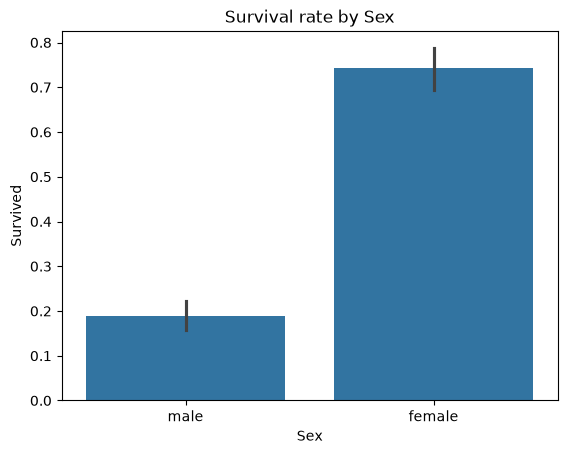

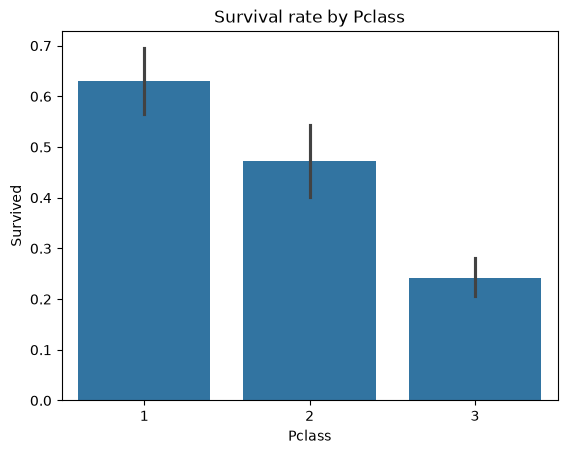

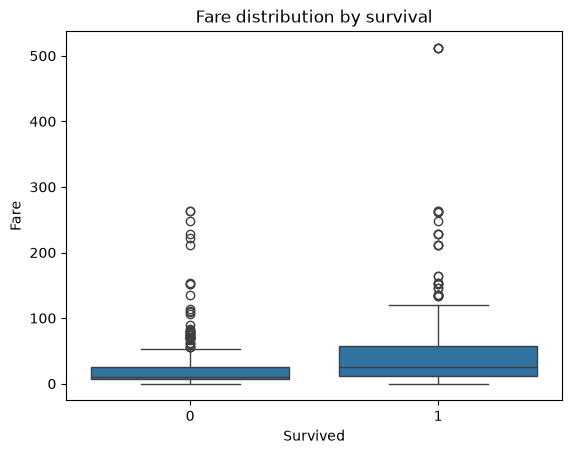

In [10]:

import matplotlib.pyplot as plt

import seaborn as sns

fig, ax = plt.subplots()

sns.barplot(data=df_work, x="Sex", y="Survived", ax=ax)

ax.set_title("Survival rate by Sex")

plt.show()

fig, ax = plt.subplots()

sns.barplot(data=df_work, x="Pclass", y="Survived", ax=ax)

ax.set_title("Survival rate by Pclass")

plt.show()

fig, ax = plt.subplots()

sns.boxplot(data=df_work, x="Survived", y="Fare", ax=ax)

ax.set_title("Fare distribution by survival")

ax.set_xlabel("Survived")

ax.set_ylabel("Fare")

plt.show()

In [11]:

display(df_work.groupby("Sex").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby("Pclass").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby(["Sex", "Pclass"]).agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


,rows,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


rows  survival_rate
Sex    Pclass                     
female 1         94       0.968085
       2         76       0.921053
       3        144       0.500000
male   1        122       0.368852
       2        108       0.157407
       3        347       0.135447

In [12]:

from scipy import stats

survived = df_work.loc[df_work["Survived"] == 1, "Fare"]

not_survived = df_work.loc[df_work["Survived"] == 0, "Fare"]

t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

print("survived Fare mean:", round(survived.mean(), 2), " n =", survived.shape[0])

print("not survived Fare mean:", round(not_survived.mean(), 2), " n =", not_survived.shape[0])

print(f"t-statistic: {t_stat:.4f}")

print(f"p-value: {p_value:.3e}")

survived Fare mean: 48.4  n = 342
not survived Fare mean: 22.12  n = 549
t-statistic: 6.8391
p-value: 2.699e-11


In [13]:
feature_demo = df_work.copy()
feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1
feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)
display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())


,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


In [14]:
model_source = pd.get_dummies(feature_demo.copy(), columns=["Sex", "Embarked"], dtype=int)

In [15]:
model_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    str    
 10  FamilySize   891 non-null    int64  
 11  IsAlone      891 non-null    int64  
 12  Sex_female   891 non-null    int64  
 13  Sex_male     891 non-null    int64  
 14  Embarked_C   891 non-null    int64  
 15  Embarked_Q   891 non-null    int64  
 16  Embarked_S   891 non-null    int64  
dtypes: float64(2), int64(12), str(3)
memory usage: 118.5 KB


In [16]:
feature_columns = [
    "Pclass",
    "Sex_female",
    "Sex_male",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S",
    "FamilySize",
    "IsAlone",
]

In [17]:
print(feature_columns)

['Pclass', 'Sex_female', 'Sex_male', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']


In [18]:
model_source[feature_columns].head()

,Pclass,Sex_female,Sex_male,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,3,0,1,22.0,1,0,7.2500,0,0,1,2,0
1,1,1,0,38.0,1,0,71.2833,1,0,0,2,0
2,3,1,0,26.0,0,0,7.9250,0,0,1,1,1
3,1,1,0,35.0,1,0,53.1000,0,0,1,2,0
4,3,0,1,35.0,0,0,8.0500,0,0,1,1,1


In [19]:
X= model_source[feature_columns].copy()
y= model_source["Survived"].astype(int).copy()

print("X",X.shape)
print("y",y.shape)

display(X.head())
display(y.head())

X (891, 12)
y (891,)


,Pclass,Sex_female,Sex_male,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,3,0,1,22.0,1,0,7.2500,0,0,1,2,0
1,1,1,0,38.0,1,0,71.2833,1,0,0,2,0
2,3,1,0,26.0,0,0,7.9250,0,0,1,1,1
3,1,1,0,35.0,1,0,53.1000,0,0,1,2,0
4,3,0,1,35.0,0,0,8.0500,0,0,1,1,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64